## Active slip velocity 

In this notebook, we compute the active slip velocity $\mathbf{v}^{\mathcal{A}}$ in terms of spherical polar coordinates $(\mathbf{\hat{\rho}},\,\mathbf{\hat{\theta}},\,\mathbf{\hat{\varphi}})$, for leading coefficients of polar, apolar and chiral symmetry. 

* We have used orientation $\mathbf{p}$ of the colloids for uniaxial parametrization of the coefficients of the slip expansion. 

* Without any loss of generality, we choose $\mathbf{p}$ to be along $\hat{\mathbf{z}}$-axis, such that $\mathbf{p}=\cos\theta\,\hat{\mathbf{\rho}}-\sin\theta\,\hat{\mathbf{\theta}}$. 

The unit vectors of the spherical coordinate and the Cartesian coordinates have the following relationship 

$$
\hat{\mathbf{\rho}}	=\sin\theta\cos\varphi\,\hat{\mathbf{x}}+\sin\theta\sin\varphi\,\hat{\mathbf{y}}+\cos\theta\,\hat{\mathbf{z}},{\displaystyle \quad\hat{\mathbf{\theta}}=\cos\theta\cos\varphi\,\hat{\mathbf{x}}+\cos\theta\sin\varphi\,\hat{\mathbf{y}}-\sin\theta\,\hat{\mathbf{z}}},{\displaystyle \quad\hat{\mathbf{\varphi}}=-\sin\varphi\,{\hat{\mathbf{x}}}+\cos\varphi\,{\hat{\mathbf{y}}}}.
$$

We assume a uniaxial parametrization of the modes such that orientation is along the $\hat{\mathbf{z}}$ axis $\mathbf{p}=\hat{\mathbf{z}}$. 



In [3]:
import numpy as np
import pyvista as pv

### Tensorial spherical harmonics (TSH)

We expand the slip $\mathbf{v}^{\mathcal{A}}$ in the expansion basis of TSH (tensorial spherical harmonics), which are
defined as (read more in S. Hess, Tensors for physics, 2015):

$$
\mathbf{Y}^{(l)}(\hat{\mathbf{ b }})
   = (-1)^l b^{l+1} \mathbf \nabla^{(l)}
  [1/{b}]  
$$

The first TSH is
$$
      Y^{(0)}(\hat{\mathbf{ b }})=1,\quad 
$$

The second TSH is:
$$
      Y_{i}^{(1)}(\hat{\mathbf{ b }})=\hat{ b }_{i},\quad 
$$

The thirs TSH is
$$
      Y_{ij}^{(2)}(\hat{\mathbf{ b }})=\left(3\hat{ b }_{i}\hat{ b }_{j}-\delta_{ij}\right).%\\
$$



### Expansion of the slip

The expansion of the slip is (read more in https://arxiv.org/abs/1910.00909):

$$
\mathbf{v}^{\mathcal{A}}(\mathbf{ b })  =
\sum_{l=1}^{\infty}
\frac{1}{(l-1)!(2l-3)!!}\,\mathbf{V}^{(l)}\cdot\mathbf{Y}^{(l-1)}(\hat{\mathcal{b}} ).
$$


The expansion coefficients $\mathbf{V} ^{(l)}$ are irreducible in $l-1$ indices and can be written in terms of irreducible tensors $\mathbf{V} ^{(l\sigma)}$, which are
are symmetric irreducible tensors of rank $l$, $l-1$ and $l-2$ for $\sigma=s,a,$
and $t$ respectively.  

We parameterize the irreducible modes of the slip in terms of TSH. 
This is a natural choice as irreducible modes of the slip are themselves symmetric traceless tensors. The expression for the mode of the slip on the $\alpha$-th particle is written in terms of its orientation $\mathbf{e}_\alpha$ as (here $V_{0}^{(l\sigma)}$ are constants):
$$
\mathbf{V} ^{(ls)}=V_{0}^{(ls)}\,\mathbf{Y}^{(l)}(\mathbf{p} ),\qquad 
    \mathbf{V} ^{(la)}=V_{0}^{(la)}\,\mathbf{Y}^{(l-1)}(\mathbf{p} ),\qquad 
    \mathbf{V} ^{(lt)}=V_{0}^{(lt)}\,\mathbf{Y}^{(l-2)}(\mathbf{p}     
$$

## 2s mode


The surface velocity due to $l\sigma=2s$ mode:

$$
\mathbf{v}^{(2s)}=V^{(2s)}_{0}\left(3\hat{\mathbf{z}}\hat{\mathbf{z}}-{\mathbb{\mathbf{I}}}\right)\cdot\hat{\mathbf{\rho}}=V^{(2s)}_{0}\left(3(\hat{\mathbf{z}}\cdot\hat{\mathbf{\rho}})\hat{\mathbf{z}}-{\hat{\mathbf{\rho}}}\right)=V^{(2s)}_{0}\left(-\sin\theta\cos\varphi\,\hat{\mathbf{x}}- \sin\theta\sin\varphi\,\hat{\mathbf{y}}+2\cos\theta\,\hat{\mathbf{z}}\right)
$$

This can be used to compute the components of the velocity in the spherical polar coordinates,

The tangential components are:
$$
v^{(2s)}_{\theta}=-\tfrac{3}{2}V^{(2s)}_{0}\sin2\theta,\qquad v^{(2s)}_{\varphi}=0
$$

A plot is given below:

/var/folders/l8/ng3lbfb14h1df_z4_lf3lnj80000gn/T/ipykernel_3943/438869859.py:53: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


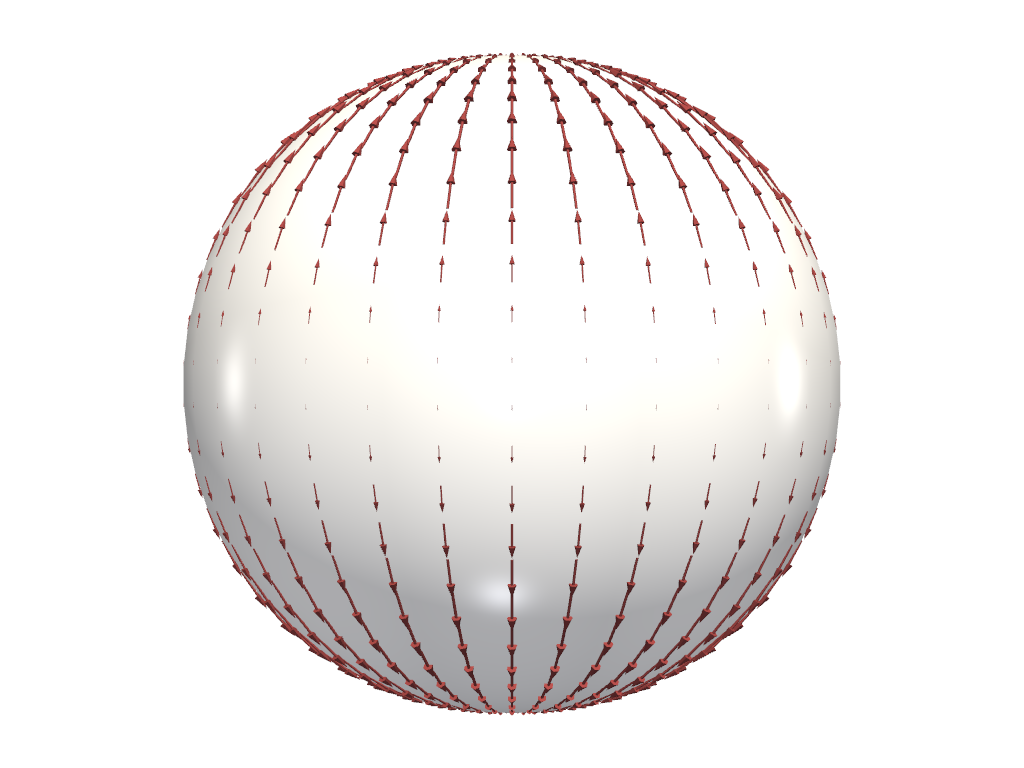

In [4]:
# 1. Create a sphere mesh
# theta_resolution controls the longitudinal lines (around Z-axis)
# phi_resolution controls the latitudinal steps (pole-to-pole)
sphere = pv.Sphere(radius=1.0, theta_resolution=32, phi_resolution=30)

# 2. Extract Cartesian coordinates of the vertices
x, y, z = sphere.points[:, 0], sphere.points[:, 1], sphere.points[:, 2]
r = np.sqrt(x**2 + y**2 + z**2)

# 3. Convert to spherical coordinates
# theta is the co-latitude (0 at North Pole, pi at South Pole)
theta = np.arccos(z / r)
phi = np.arctan2(y, x)

# 4. Compute the components of the vector field: V = sin(theta) * theta_hat
# Where theta_hat = [cos(theta)*cos(phi), cos(theta)*sin(phi), -sin(theta)]
magnitude = -1.5*np.sin(2*theta)

vx = magnitude * np.cos(theta) * np.cos(phi)
vy = magnitude * np.cos(theta) * np.sin(phi)
vz = -magnitude * np.sin(theta)

# Assign the vector data to the mesh points
sphere['vectors'] = np.column_stack((vx, vy, vz))

# 5. Generate the vector arrows (glyphs)
# 'scale' scales the arrow length by the vector magnitude (sin(theta))
arrows = sphere.glyph(orient='vectors', scale='vectors', factor=0.1)

# 6. Set up the PyVista plotter for a clean, glossy look
plotter = pv.Plotter()
plotter.background_color = 'white'

# Add the white base sphere with smooth shading and specular highlights
plotter.add_mesh(
    sphere,
    color='#fcfbfa',       # Off-white color matching your image
    smooth_shading=True,
    specular=0.87,          # Adds the shiny reflection
    specular_power=123,     # Controls the focus of the highlight
    ambient=0.29            # Softens the shadows
)

# Add the vector arrows in blue
plotter.add_mesh(arrows, color='indianred')

# Clean up the view (remove axes and zoom in slightly)
plotter.hide_axes()
plotter.camera_position = 'xz'
plotter.camera.zoom(1.5)

# Display the interactive plot
plotter.show()

## 3t mode


The surface velocity due to $l\sigma=3t$ mode:

$$
\mathbf{v}^{(3t)}=V^{(3t)}_{0}\hat{\mathbf{z}}\cdot\left(3\hat{\mathbf{\rho}}\hat{\mathbf{\rho}}-{\mathbb{\mathbf{I}}}\right)=V^{(3t)}_{0}\left((\hat{\mathbf{\rho}}\cdot\hat{\mathbf{z}})\hat{\mathbf{\rho}}-\tfrac{1}{3}\hat{\mathbf{z}}\right)
=3V^{(3t)}_{0}\left(\sin\theta\cos\theta\cos\varphi\,\hat{\mathbf{x}}+\sin\theta\cos\theta\sin\varphi\,\hat{\mathbf{y}}+\left(\cos^{2}\theta-\tfrac{1}{3}\right)\hat{\mathbf{z}}\right).
$$

$$
v^{(3t)}_{\theta}=\mathbf{v}^{(3t)}\cdot\hat{\boldsymbol{\theta}}=3V^{(3t)}_{0}\left(\sin\theta\cos^{2}\theta\cos^{2}\varphi+\sin\theta\cos^{2}\theta\sin^{2}\varphi-\sin\theta\left(\cos^{2}\theta-\tfrac{1}{3}\right)\right)= V^{(3t)}_{0}\sin\theta,
$$

$$
v^{(3t)}_{\varphi}=\mathbf{v}^{(3t)}\cdot\hat{\boldsymbol{\varphi}}=3V^{(3t)}_{0}\left(-\sin\theta\cos\theta\sin\varphi\cos\varphi+\sin\theta\cos\theta\sin\varphi\cos\varphi\right)=0.
$$

/var/folders/l8/ng3lbfb14h1df_z4_lf3lnj80000gn/T/ipykernel_3943/2280440063.py:53: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


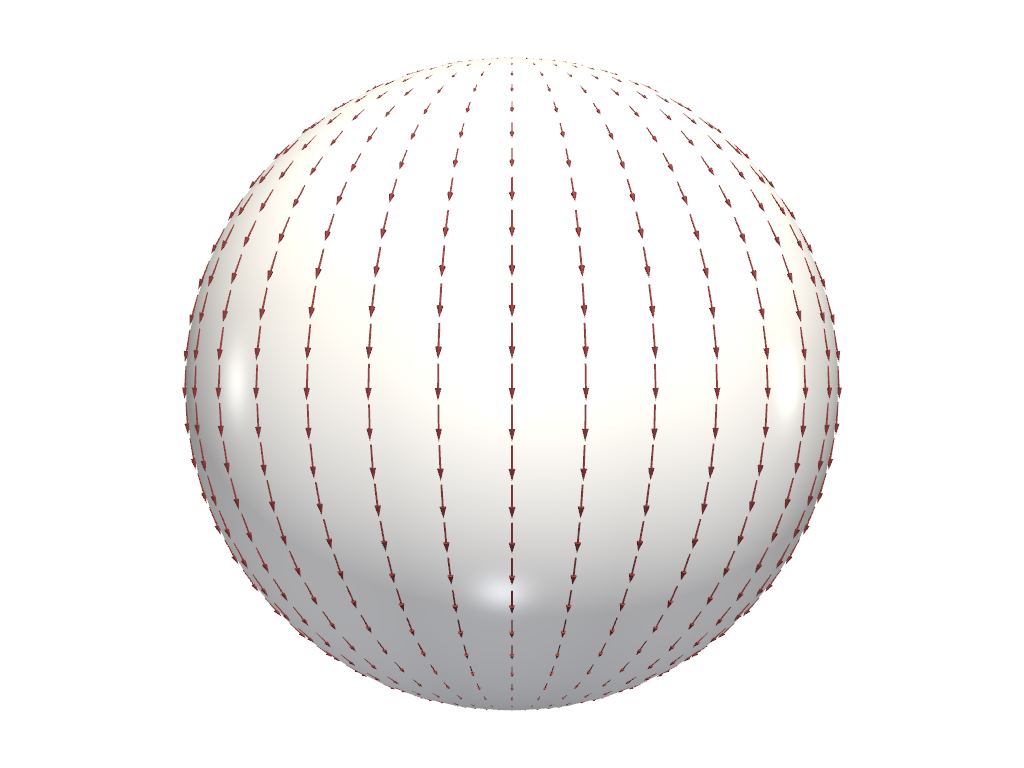

In [5]:


# 1. Create a sphere mesh
# theta_resolution controls the longitudinal lines (around Z-axis)
# phi_resolution controls the latitudinal steps (pole-to-pole)
sphere = pv.Sphere(radius=1.0, theta_resolution=32, phi_resolution=30)

# 2. Extract Cartesian coordinates of the vertices
x, y, z = sphere.points[:, 0], sphere.points[:, 1], sphere.points[:, 2]
r = np.sqrt(x**2 + y**2 + z**2)

# 3. Convert to spherical coordinates
# theta is the co-latitude (0 at North Pole, pi at South Pole)
theta = np.arccos(z / r)
phi = np.arctan2(y, x)

# 4. Compute the components of the vector field: V = sin(theta) * theta_hat
# Where theta_hat = [cos(theta)*cos(phi), cos(theta)*sin(phi), -sin(theta)]
magnitude = np.sin(theta)

vx = magnitude * np.cos(theta) * np.cos(phi)
vy = magnitude * np.cos(theta) * np.sin(phi)
vz = -magnitude * np.sin(theta)

# Assign the vector data to the mesh points
sphere['vectors'] = np.column_stack((vx, vy, vz))

# 5. Generate the vector arrows (glyphs)
# 'scale' scales the arrow length by the vector magnitude (sin(theta))
arrows = sphere.glyph(orient='vectors', scale='vectors', factor=0.1)

# 6. Set up the PyVista plotter for a clean, glossy look
plotter = pv.Plotter()
plotter.background_color = 'white'

# Add the white base sphere with smooth shading and specular highlights
plotter.add_mesh(
    sphere,
    color='#fcfbfa',       # Off-white color matching your image
    smooth_shading=True,
    specular=0.87,          # Adds the shiny reflection
    specular_power=123,     # Controls the focus of the highlight
    ambient=0.29            # Softens the shadows
)

# Add the vector arrows in blue
plotter.add_mesh(arrows, color='indianred')

# Clean up the view (remove axes and zoom in slightly)
plotter.hide_axes()
plotter.camera_position = 'xz'
plotter.camera.zoom(1.5)

# Display the interactive plot
plotter.show()

## 3a mode

$$
\mathbf{v}^{(3a)}=-V^{(3a)}_{0}2\boldsymbol{\varepsilon}\cdot\left(3\hat{\boldsymbol{z}}\hat{\boldsymbol{z}}-{\mathbb{\mathbf{I}}} \right)\cdot\left(3\hat{\boldsymbol{\rho}}\hat{\boldsymbol{\rho}}- {\mathbb{\mathbf{I}}} \right)=-18V^{(3a)}_{0}\left((\hat{\boldsymbol{\rho}}\cdot\hat{\boldsymbol{z}})(\hat{\boldsymbol{\rho}}\times\hat{\boldsymbol{z}})\right)=9V^{(3a)}_{0}\left(\sin\theta\cos\theta\sin\varphi\,\hat{\boldsymbol{x}}-\sin\theta\cos\theta\cos\varphi\,\hat{\boldsymbol{y}}\right).
$$

The components in tangential direction are:

$$
v^{(3a)}_{\theta}=0,
$$

$$
v^{(3a)}_{\varphi}=V^{(3a)}_{0}\sin2\theta.
$$

/var/folders/l8/ng3lbfb14h1df_z4_lf3lnj80000gn/T/ipykernel_3943/1098730814.py:53: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


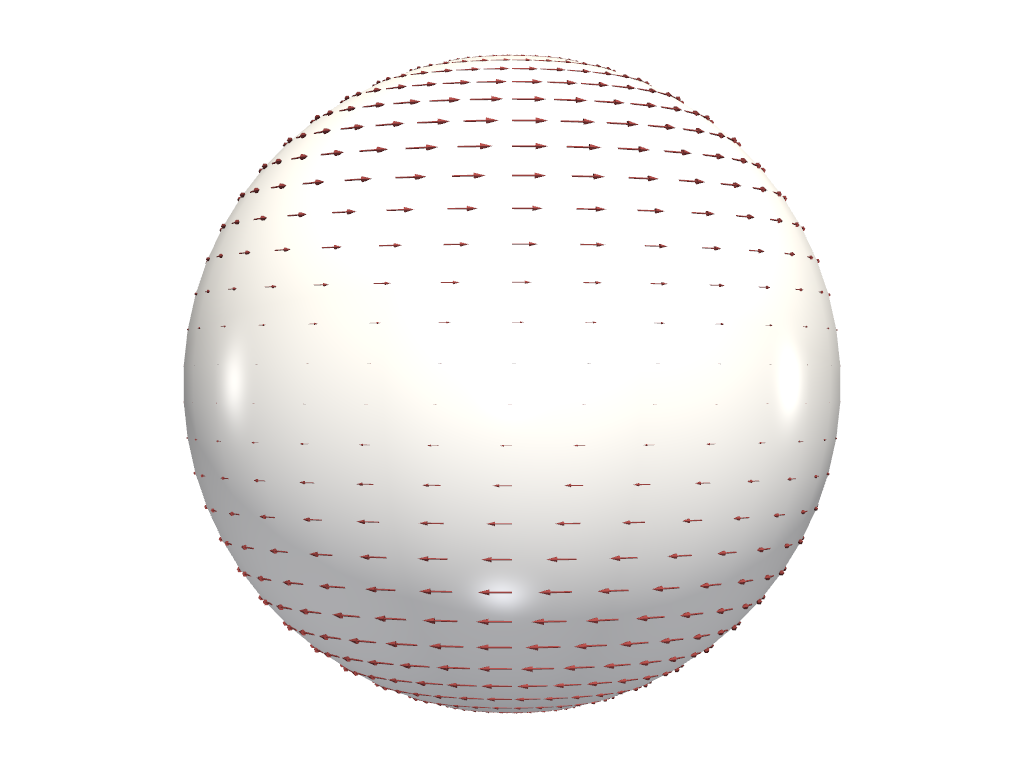

In [6]:


# 1. Create a sphere mesh
# theta_resolution controls the longitudinal lines (around Z-axis)
# phi_resolution controls the latitudinal steps (pole-to-pole)
sphere = pv.Sphere(radius=1.0, theta_resolution=32, phi_resolution=30)

# 2. Extract Cartesian coordinates of the vertices
x, y, z = sphere.points[:, 0], sphere.points[:, 1], sphere.points[:, 2]
r = np.sqrt(x**2 + y**2 + z**2)

# 3. Convert to spherical coordinates
# theta is the co-latitude (0 at North Pole, pi at South Pole)
theta = np.arccos(z / r)
phi = np.arctan2(y, x)

# 4. Compute the components of the vector field: V = sin(theta) * theta_hat
# Where phi_hat = [-sin(phi), cos(phi), 0]
magnitude = np.sin(2 * theta)

vx = -magnitude * np.sin(phi)
vy = magnitude * np.cos(phi)
vz = np.zeros_like(theta)

# Assign the vector data to the mesh points
sphere['vectors'] = np.column_stack((vx, vy, vz))

# 5. Generate the vector arrows (glyphs)
# 'scale' scales the arrow length by the vector magnitude (sin(theta))
arrows = sphere.glyph(orient='vectors', scale='vectors', factor=0.1)

# 6. Set up the PyVista plotter for a clean, glossy look
plotter = pv.Plotter()
plotter.background_color = 'white'

# Add the white base sphere with smooth shading and specular highlights
plotter.add_mesh(
    sphere,
    color='#fcfbfa',       # Off-white color matching your image
    smooth_shading=True,
    specular=0.87,          # Adds the shiny reflection
    specular_power=123,     # Controls the focus of the highlight
    ambient=0.29            # Softens the shadows
)

# Add the vector arrows in blue
plotter.add_mesh(arrows, color='indianred')

# Clean up the view (remove axes and zoom in slightly)
plotter.hide_axes()
plotter.camera_position = 'xz'
plotter.camera.zoom(1.5)

# Display the interactive plot
plotter.show()

## 4a mode

The components in tangential direction are:



$$
v^{(4a)}_{\theta}=0,$$

$$
v^{(4a)}_{\varphi}=V^{(4a)}_{0}\left(\cos^{2}\theta-\tfrac{1}{5}\right)\sin\theta
$$

/var/folders/l8/ng3lbfb14h1df_z4_lf3lnj80000gn/T/ipykernel_3943/2838207121.py:53: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


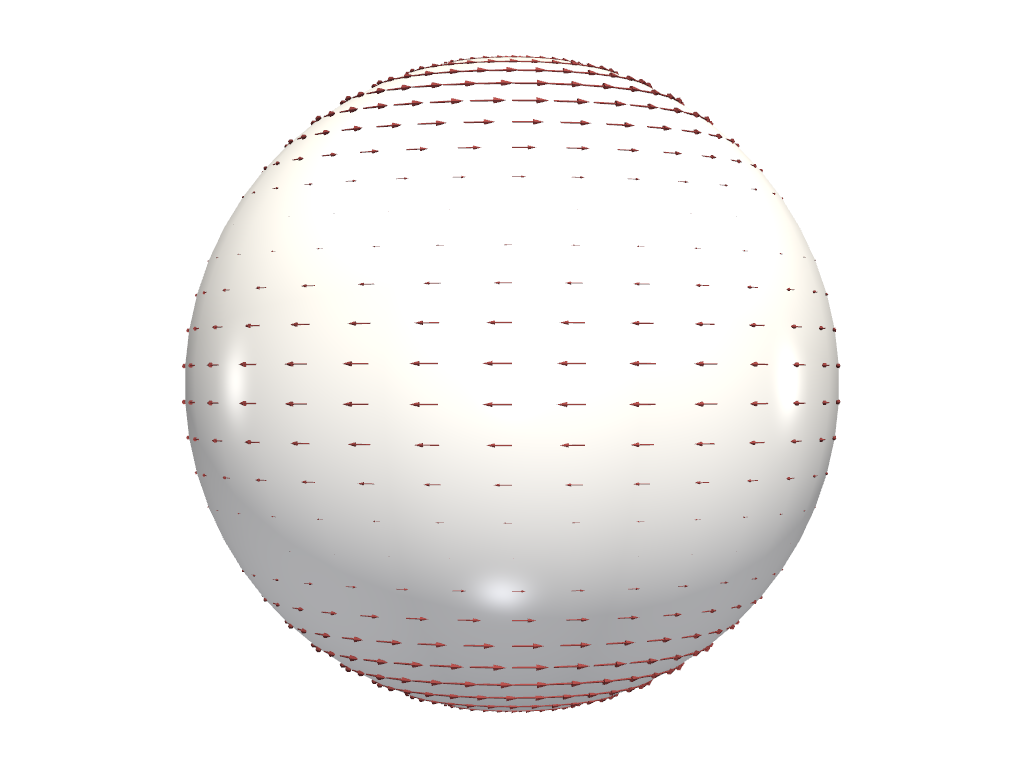

In [7]:


# 1. Create a sphere mesh
# theta_resolution controls the longitudinal lines (around Z-axis)
# phi_resolution controls the latitudinal steps (pole-to-pole)
sphere = pv.Sphere(radius=1.0, theta_resolution=32, phi_resolution=30)

# 2. Extract Cartesian coordinates of the vertices
x, y, z = sphere.points[:, 0], sphere.points[:, 1], sphere.points[:, 2]
r = np.sqrt(x**2 + y**2 + z**2)

# 3. Convert to spherical coordinates
# theta is the co-latitude (0 at North Pole, pi at South Pole)
theta = np.arccos(z / r)
phi = np.arctan2(y, x)

# 4. Compute the components of the vector field: V = sin(theta) * theta_hat
# Where phi_hat = [-sin(phi), cos(phi), 0]
magnitude = np.sin(theta)*(np.cos(theta)*np.cos(theta) - 0.2)

vx = -magnitude * np.sin(phi)
vy = magnitude * np.cos(phi)
vz = np.zeros_like(theta)

# Assign the vector data to the mesh points
sphere['vectors'] = np.column_stack((vx, vy, vz))

# 5. Generate the vector arrows (glyphs)
# 'scale' scales the arrow length by the vector magnitude (sin(theta))
arrows = sphere.glyph(orient='vectors', scale='vectors', factor=0.4)

# 6. Set up the PyVista plotter for a clean, glossy look
plotter = pv.Plotter()
plotter.background_color = 'white'

# Add the white base sphere with smooth shading and specular highlights
plotter.add_mesh(
    sphere,
    color='#fcfbfa',       # Off-white color matching your image
    smooth_shading=True,
    specular=0.87,          # Adds the shiny reflection
    specular_power=123,     # Controls the focus of the highlight
    ambient=0.29            # Softens the shadows
)

# Add the vector arrows in blue
plotter.add_mesh(arrows, color='indianred')

# Clean up the view (remove axes and zoom in slightly)
plotter.hide_axes()
plotter.camera_position = 'xz'
plotter.camera.zoom(1.5)

# Display the interactive plot
plotter.show()